In [1]:
from google.colab import drive

drive.mount('/content/drive')
path = '/content/drive/MyDrive/Datasheet/credit_card_fraud_10k.csv'

Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_csv(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [4]:
df.isnull().sum()

,0
transaction_id,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [7]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,9849
1,151


In [8]:
df['is_fraud'].value_counts(normalize=True)*100

,proportion
is_fraud,
0,98.49
1,1.51


In [9]:
df.drop(columns='transaction_id',inplace=True)

In [11]:
df.head(5)

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,84.47,22,Electronics,0,0,66,3,40,0
1,541.82,3,Travel,1,0,87,1,64,0
2,237.01,17,Grocery,0,0,49,1,61,0
3,164.33,4,Grocery,0,1,72,3,34,0
4,30.53,15,Food,0,0,79,0,44,0


In [10]:
df.columns

Index(['amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

**Feature Engineering**

In [12]:
import numpy as np

df['hour_sin'] = np.sin(2 * np.pi * df['transaction_hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['transaction_hour']/24)

In [13]:
df.columns

Index(['amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud', 'hour_sin',
       'hour_cos'],
      dtype='object')

**Preprocessing**

In [14]:
Feature = ['amount','hour_sin','hour_cos','foreign_transaction','location_mismatch','device_trust_score','velocity_last_24h','cardholder_age']
X = df[Feature]
y = df['is_fraud']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)
print(f'Jumlah data uji :{len(X_test)} dan jumlah data latih :{len(X_train)}')

Jumlah data uji :2000 dan jumlah data latih :8000


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_feature = ['amount','device_trust_score','velocity_last_24h','cardholder_age']
num_transform = scaler

In [18]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', num_transform, num_feature)
], remainder = 'passthrough')

In [19]:
from sklearn.ensemble import GradientBoostingClassifier

baseline_gradient = GradientBoostingClassifier(random_state=42)

**Model Baseline**

In [20]:
from sklearn.pipeline import Pipeline

baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', baseline_gradient)
])

In [21]:
baseline_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('model', GradientBoostingClassifier(random_state=42))])

In [22]:
y_pred_baseline = baseline_pipeline.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, roc_auc_score, confusion_matrix

accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline)
recall_baseline = recall_score(y_test, y_pred_baseline)
print(f'Akurasi model baseline :{accuracy_baseline:.4f}')
print(f'Precision model baseline :{precision_baseline:.4f}')
print(f'Recall model baseline :{recall_baseline:.4f}')
print(classification_report(y_test, y_pred_baseline))

Akurasi model baseline :0.9965
Precision model baseline :0.8966
Recall model baseline :0.8667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       0.90      0.87      0.88        30

    accuracy                           1.00      2000
   macro avg       0.95      0.93      0.94      2000
weighted avg       1.00      1.00      1.00      2000



In [24]:
y_prob_baseline = baseline_pipeline.predict_proba(X_test)[:,1]

In [25]:
roc_auc_baseline = roc_auc_score(y_test, y_prob_baseline)
print(f'ROC AUC score model baseline :{roc_auc_baseline:.4f}')

ROC AUC score model baseline :0.9994


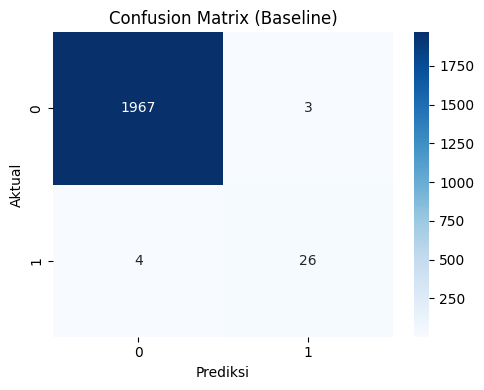

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_baseline = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(5,4))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Baseline)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

**SMOTE + GradientBoosting**

In [27]:
from imblearn.pipeline import Pipeline as imbPipeline
from imblearn.over_sampling import SMOTE

smote_pipeline = imbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', baseline_gradient)
])

In [28]:
smote_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', GradientBoostingClassifier(random_state=42))])

In [29]:
y_pred_smote = smote_pipeline.predict(X_test)

In [31]:
accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
print(f'Akurasi model SMOTE :{accuracy_smote:.4f}')
print(f'Precision model SMOTE :{precision_smote:.4f}')
print(f'Recall model SMOTE : {recall_smote:.4f}')
print(classification_report(y_test, y_pred_smote))

Akurasi model SMOTE :0.9935
Precision model SMOTE :0.7073
Recall model SMOTE : 0.9667
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1970
           1       0.71      0.97      0.82        30

    accuracy                           0.99      2000
   macro avg       0.85      0.98      0.91      2000
weighted avg       1.00      0.99      0.99      2000



In [32]:
y_prob_smote = smote_pipeline.predict_proba(X_test)[:,1]

In [33]:
roc_auc_smote = roc_auc_score(y_test, y_prob_smote)
print(f'ROC AUC score model SMOTE :{roc_auc_smote:.4f}')

ROC AUC score model SMOTE :0.9994


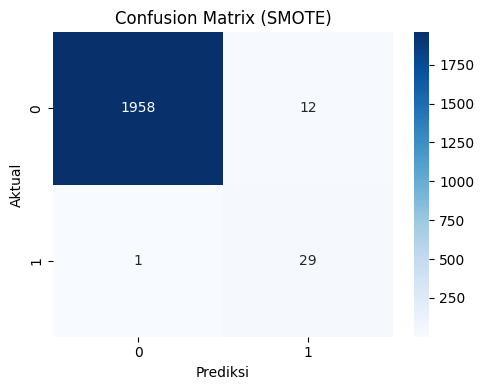

In [34]:
cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(5,4))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (SMOTE)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

**Model Hyperparameter Tuning Menggunakan Model SMOTE**

In [45]:
params_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [4, 5, 6],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [2, 4],
    'model__subsample': [0.8, 1.0]
}

In [46]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=smote_pipeline,
    param_grid=params_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [47]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['amount',
                                                                          'device_trust_score',
                                                                          'velocity_last_24h',
                                                                          'cardholder_age'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model',
                                        GradientBoostingClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.01, 0.05, 0.1],
                         'model__max_depth': [4, 5, 6],
                         'model__min_samples_leaf': [2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 200],
                         'model__subsample': [0.8, 1.0]},
             scoring='f1', verbose=1)

In [48]:
print(grid_search.best_params_)

{'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100, 'model__subsample': 0.8}


In [49]:
best_GradientBoosting = grid_search.best_estimator_

In [50]:
y_pred = best_GradientBoosting.predict(X_test)

In [51]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f'Akurasi model Gradient Boosting :{accuracy:.4f}')
print(f'Precision model Gradient Boosting :{precision:.4f}')
print(f'Recall model Gradient Boosting :{recall:.4f}')
print(classification_report(y_test, y_pred))

Akurasi model Gradient Boosting :0.9990
Precision model Gradient Boosting :0.9375
Recall model Gradient Boosting :1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       0.94      1.00      0.97        30

    accuracy                           1.00      2000
   macro avg       0.97      1.00      0.98      2000
weighted avg       1.00      1.00      1.00      2000



In [52]:
y_prob = best_GradientBoosting.predict_proba(X_test)[:,1]

In [53]:
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC AUC score model Gradient Boosting :{roc_auc:.4f}")

ROC AUC score model Gradient Boosting :0.9999


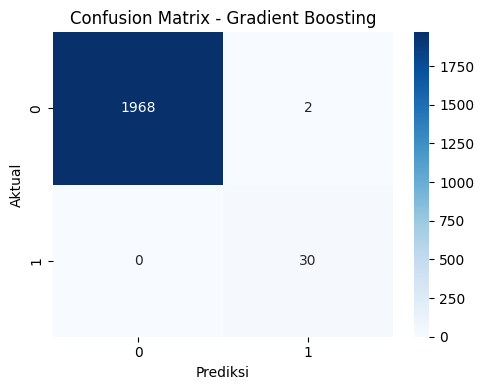

In [54]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

In [55]:
feature_names = X.columns

importance = pd.DataFrame({
    'Feature' : feature_names,
    'Importance' : best_GradientBoosting.named_steps['model'].feature_importances_
})

In [56]:
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

In [57]:
print(importance)

               Feature  Importance
1             hour_sin    0.378943
6    velocity_last_24h    0.200646
2             hour_cos    0.158950
7       cardholder_age    0.109202
5   device_trust_score    0.102816
4    location_mismatch    0.024647
0               amount    0.023438
3  foreign_transaction    0.001358


/tmp/ipykernel_4317/741465779.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


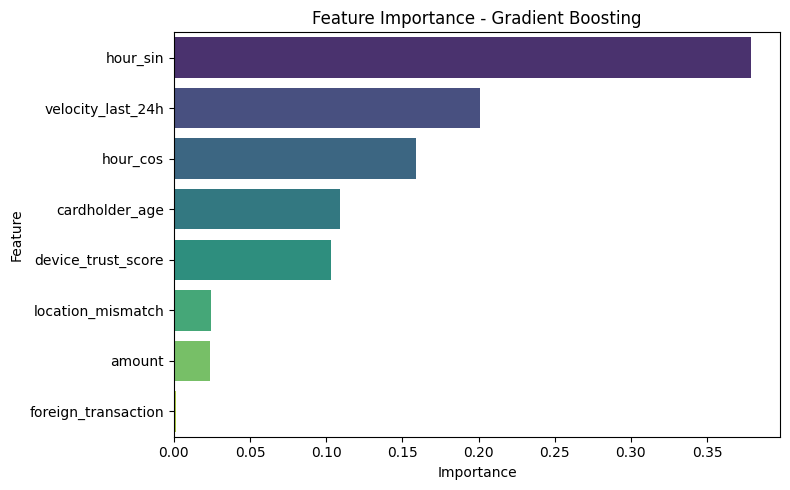

In [58]:
plt.figure(figsize=(8,5))
sns.barplot(
    data = importance,
    x = 'Importance',
    y = 'Feature',
    palette = 'viridis'
)
plt.title('Feature Importance - Gradient Boosting')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [59]:
from google.colab import files
import joblib

joblib.dump(best_GradientBoosting, 'Gradient_Boosting_Model.joblib')
files.download('Gradient_Boosting_Model.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>